In [58]:
import wrds
import pandas as pd

In [59]:
username = "YOUR_WRDS_USERNAME"
db = wrds.Connection(wrds_username=username)

WRDS recommends setting up a .pgpass file.
pgpass file created at C:\Users\ASUS\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [37]:
pip install matplotlib scipy pandas numpy statsmodels scikit-learn seaborn

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd                #数据工具
import matplotlib.pyplot as plt    #画图工具
from scipy import stats            #回归图表库
import numpy as np                 #数学计算工具

In [6]:
import statsmodels.api as sm

In [7]:
china_financial_data = db.raw_sql("""
SELECT stkcd, accper, typrep, a001000000, b001100000, c001000000, a002000000    
FROM csmar.wrds_csmar_financial_master
WHERE accper BETWEEN '2020-01-01' AND '2024-12-31'
  AND typrep = 'A'
  AND a001000000 > 0
  AND b001100000 > 0
""")

china_financial_data

,stkcd,accper,typrep,a001000000,b001100000,c001000000,a002000000
0,000001,2020-01-01,A,3939070000000.0,126814000000.0,-40025000000.0,3626087000000.0
1,000001,2020-03-31,A,4132298000000.0,34483000000.0,17989000000.0,3779943000000.0
2,000001,2020-06-30,A,4178622000000.0,70071000000.0,-25666000000.0,3827225000000.0
3,000001,2020-09-30,A,4346921000000.0,107455000000.0,30698000000.0,3988150000000.0
4,000001,2020-12-31,A,4468514000000.0,143242000000.0,-16161000000.0,4104383000000.0
...,...,...,...,...,...,...,...
125526,920819,2024-01-01,A,12642144017.440001,5868305351.83,38227051.23,6853604881.19
125527,920819,2024-03-31,A,12801345164.290001,1374078857.91,-159307829.82,7051031167.01
125528,920819,2024-06-30,A,12734196624.68,2878968888.16,-131027658.97,7183918627.08
125529,920819,2024-09-30,A,12393726152.700001,4327541477.66,-46058300.49,6996306391.86


In [61]:
#Remove the impact of quarterly reports and retain only the annual reports.
china_financial_data['accper'] = china_financial_data['accper'].astype(str)
df_step1 = china_financial_data[china_financial_data['accper'].str.endswith('-12-31')].copy()
df_step1 = df_step1.drop_duplicates(subset=['stkcd', 'accper'], keep='first')

print("Processed data", len(df_step1))
print("The first five values of the accper：")
print(df_step1['accper'].head())

Processed data 25796
The first five values of the accper：
4     2020-12-31
9     2021-12-31
14    2022-12-31
19    2023-12-31
24    2024-12-31
Name: accper, dtype: str


In [62]:
#Re-import the modified date data back into the table
cols_keep = ['stkcd', 'accper', 'a001000000', 'b001100000', 'c001000000', 'a002000000']
df_step2 = df_step1[cols_keep].copy()

print("data size", df_step2.shape)
print("\ntype of each column：")
print(df_step2.dtypes)
print("\nfirst five rows：")
print(df_step2.head())

data size (25796, 6)

type of each column：
stkcd          string
accper            str
a001000000    Float64
b001100000    Float64
c001000000    Float64
a002000000    Float64
dtype: object

first five rows：
     stkcd      accper       a001000000      b001100000      c001000000  \
4   000001  2020-12-31  4468514000000.0  143242000000.0  -16161000000.0   
9   000001  2021-12-31  4921380000000.0  153503000000.0 -192733000000.0   
14  000001  2022-12-31  5321514000000.0  160469000000.0  134572000000.0   
19  000001  2023-12-31  5587116000000.0  147959000000.0   92461000000.0   
24  000001  2024-12-31  5769270000000.0  117921000000.0   63336000000.0   

         a002000000  
4   4104383000000.0  
9   4525932000000.0  
14  4886834000000.0  
19  5114788000000.0  
24  5274428000000.0  


In [63]:
#Remove the null values from the data to ensure the normal operation of the calculation.
cols_raw = ['a001000000', 'b001100000', 'c001000000', 'a002000000']
df_step3 = df_step2.dropna(subset=cols_raw).copy()

print("processed data：", len(df_step3))
print("\nnumber of missing values：")
print(df_step3[cols_raw].isnull().sum())

processed data： 25795

number of missing values：
a001000000    0
b001100000    0
c001000000    0
a002000000    0
dtype: int64


In [64]:
#Keep the positive numbers to avoid any problems when calculating ROA and the asset-liability ratio.
df_step4 = df_step3[
    (df_step3['a001000000'] > 0) &   
    (df_step3['b001100000'] > 0)     
].copy()

print("processed data：", len(df_step4))

processed data： 25795


In [65]:
# calculate ROA & Leverage ratio
df_step5 = df_step4.copy()

#ROA
df_step5['roa'] = df_step5['c001000000'] / df_step5['a001000000']

#Leverage
df_step5['lev'] = df_step5['a002000000'] / df_step5['a001000000']

#Take the logarithm to ensure the regression effect
df_step5['log_at'] = np.log(df_step5['a001000000'])
df_step5['log_revt'] = np.log(df_step5['b001100000'])

# ---------------------- 检查第五步结果 ----------------------
print("ok!")
print("row sizw：", len(df_step5))
print("\nfirst 5 rows of the new datas：")
print(df_step5[['roa', 'lev', 'log_at', 'log_revt']].head())
print("\nnew type：")
print(df_step5[['roa', 'lev', 'log_at', 'log_revt']].dtypes)

ok!
row sizw： 25795

first 5 rows of the new datas：
         roa       lev     log_at   log_revt
4  -0.003617  0.918512  29.128077  25.687801
9  -0.039162  0.919647   29.22461  25.756986
14  0.025288  0.918316  29.302779  25.801367
19  0.016549  0.915461  29.351484  25.720201
24  0.010978  0.914228  29.383567  25.493281

new type：
roa         Float64
lev         Float64
log_at      Float64
log_revt    Float64
dtype: object


In [66]:
#Eliminate outliers
cols_reg = ['log_revt', 'log_at', 'roa', 'lev']

#Remove null values
df_step6 = df_step5.dropna(subset=cols_reg).copy()

#Eliminate positive and negative infinity
df_step6 = df_step6[np.isfinite(df_step6[cols_reg]).all(axis=1)]

# ------------ ----------------------
print("Final cleaning completed!")
print("row size：", len(df_step6))
print("\nThe number of missing values for each variable：")
print(df_step6[cols_reg].isnull().sum())

Final cleaning completed!
row size： 25795

The number of missing values for each variable：
log_revt    0
log_at      0
roa         0
lev         0
dtype: int64


In [67]:
#LinearRegression
from sklearn.linear_model import LinearRegression
import numpy as np

X = df_step6[['log_at', 'roa', 'lev']].values
y = df_step6['log_revt'].values

model = LinearRegression()
model.fit(X, y)

print("Regression coefficient：", model.coef_)
print("intercept：", model.intercept_)
print("R²：", model.score(X, y))

Regression coefficient： [ 8.94684513e-01  2.18406653e+00 -2.05885352e-03]
intercept： 1.4208859321808731
R²： 0.7648945928198064


In [ ]:
# Force conversion to a pure numpy float64 array to resolve the incompatibility issue
X = np.asarray(df_step6[['log_at', 'roa', 'lev']], dtype=np.float64)
y = np.asarray(df_step6['log_revt'], dtype=np.float64)
#Output the complete regression results
X = sm.add_constant(X)
model = sm.OLS(y, X).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.765
Model:                            OLS   Adj. R-squared:                  0.765
Method:                 Least Squares   F-statistic:                 1.184e+04
Date:                Wed, 22 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:19:05   Log-Likelihood:                -30235.
No. Observations:               25795   AIC:                         6.048e+04
Df Residuals:                   25791   BIC:                         6.051e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.4209      0.279      5.089      0.0

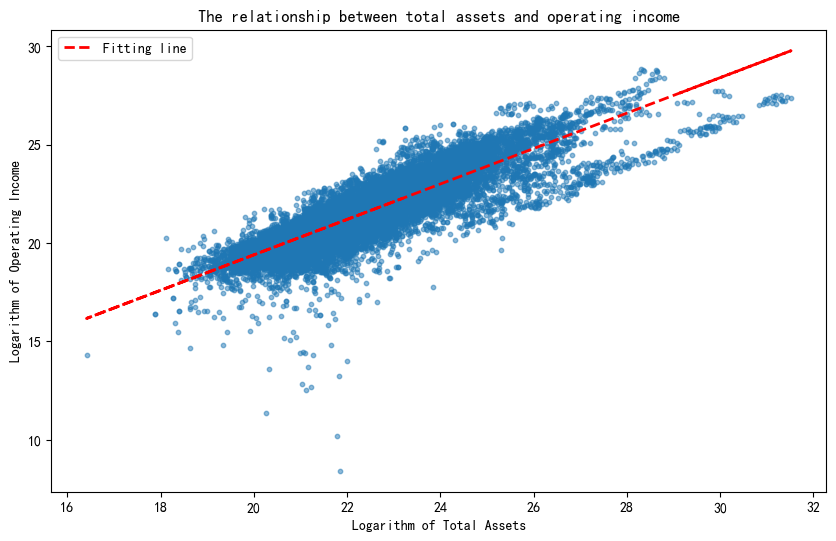

In [68]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10,6))
plt.scatter(df_step6['log_at'], df_step6['log_revt'], s=10, alpha=0.5)
plt.xlabel('Logarithm of Total Assets')
plt.ylabel('Logarithm of Operating Income')
plt.title('The relationship between total assets and operating income')

z = np.polyfit(df_step6['log_at'], df_step6['log_revt'], 1)
p = np.poly1d(z)
plt.plot(df_step6['log_at'], p(df_step6['log_at']), 'r--', lw=2, label='Fitting line')
plt.legend()
plt.show()

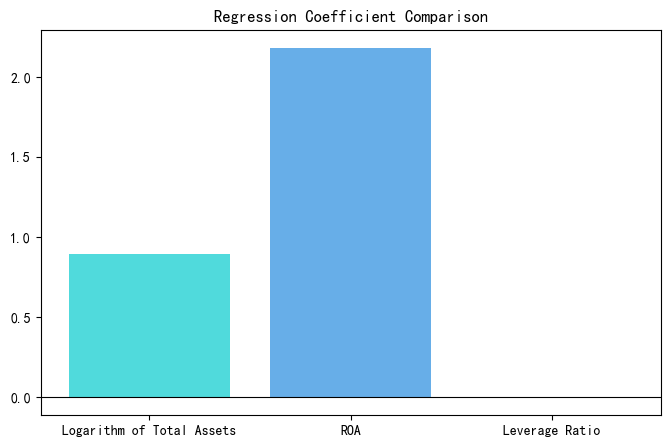

In [ ]:
coefs = model.coef_  
names = ['Logarithm of Total Assets', 'ROA', 'Leverage Ratio']

plt.figure(figsize=(8,5))
plt.bar(names, coefs, color=["#50dadc", "#67aee8", '#2ca02c'])
plt.title('Regression Coefficient Comparison')
plt.axhline(0, color='black', linewidth=0.8)
plt.show()

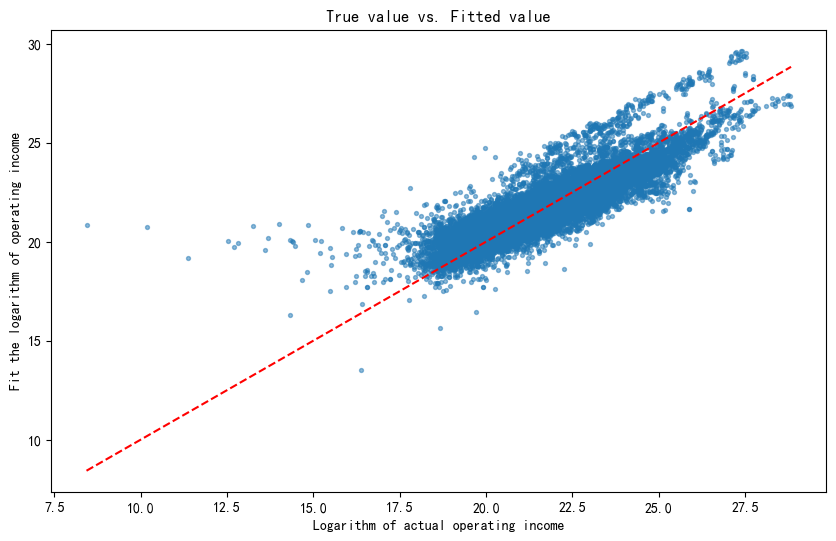

In [72]:
y_fit = model.predict(X)

plt.figure(figsize=(10,6))
plt.scatter(y, y_fit, s=8, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Logarithm of actual operating income')
plt.ylabel('Fit the logarithm of operating income')
plt.title('True value vs. Fitted value')
plt.show()

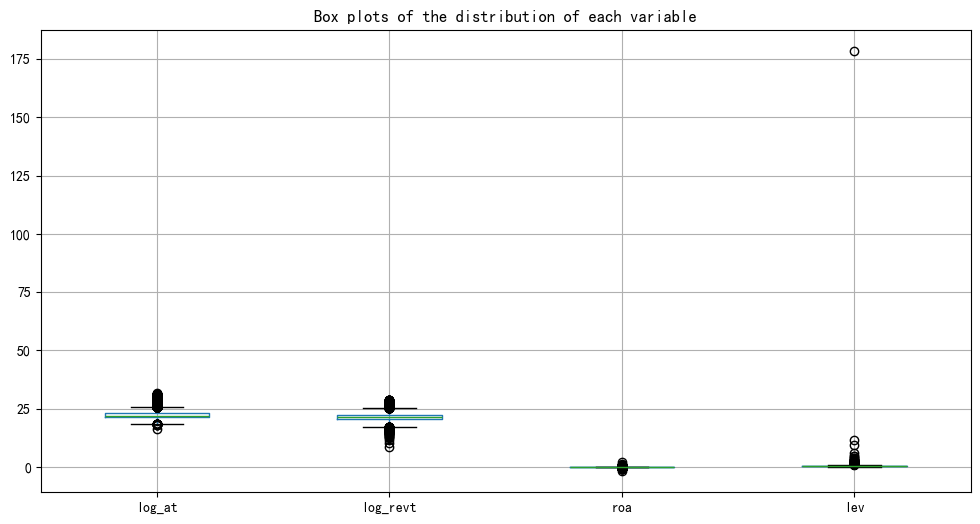

In [73]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 图1：变量箱线图（和你的变量名完全对应）
df_step6[['log_at', 'log_revt', 'roa', 'lev']].boxplot(figsize=(12,6))
plt.title('Box plots of the distribution of each variable')
plt.show()

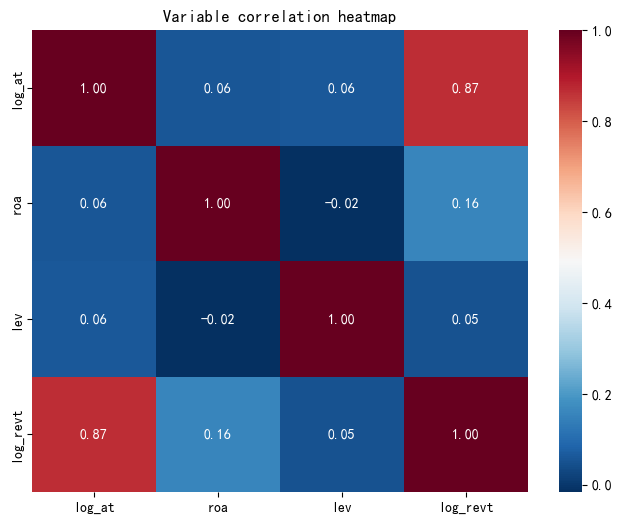

In [74]:
import seaborn as sns
corr = df_step6[['log_at', 'roa', 'lev', 'log_revt']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='RdBu_r', fmt='.2f')
plt.title('Variable correlation heatmap')
plt.show()

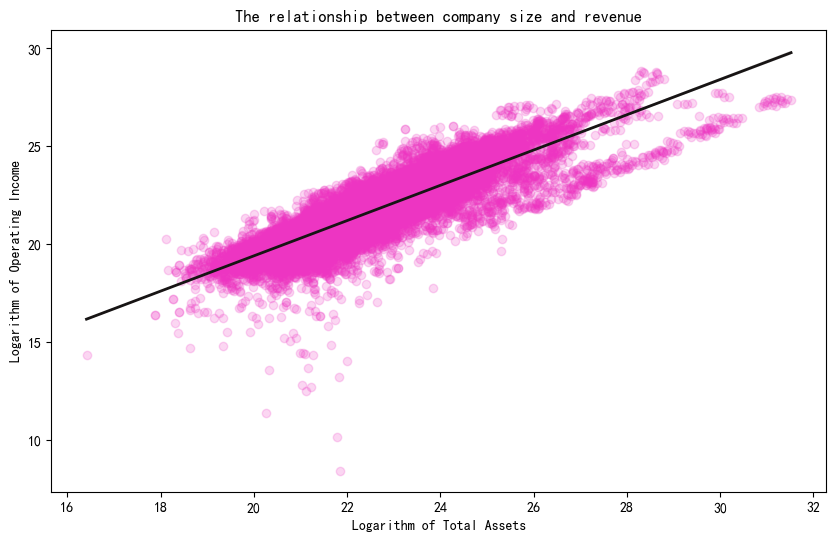

In [75]:
plt.figure(figsize=(10,6))
sns.regplot(x=df_step6['log_at'], y=df_step6['log_revt'], scatter_kws={'color':"#ED35C2", 'alpha':0.2}, line_kws={'color':"#171414", 'lw':2}) 
plt.xlabel('Logarithm of Total Assets')
plt.ylabel('Logarithm of Operating Income')
plt.title('The relationship between company size and revenue')
plt.show()

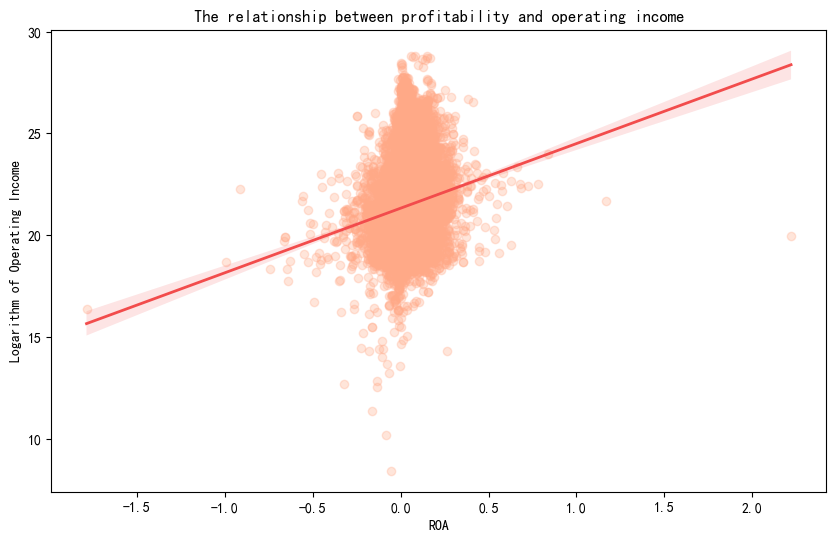

In [76]:
plt.figure(figsize=(10,6))
# 散点用浅橙，拟合线用深橙
sns.regplot(x=df_step6['roa'], y=df_step6['log_revt'], 
            scatter_kws={'color':'#FFA987', 'alpha':0.3},
            line_kws={'color':'#F24C4C', 'lw':2})
plt.xlabel('ROA')
plt.ylabel('Logarithm of Operating Income')
plt.title('The relationship between profitability and operating income')
plt.show()

In [77]:
#Examine abnormal values of leverage ratio
df_clean = df_step6[(df_step6['lev'] >= 0) & (df_step6['lev'] <= 1)]

print(df_clean['lev'].describe())

count     25627.0
mean      0.41757
std      0.215176
min      0.013062
25%      0.245135
50%      0.402784
75%      0.567778
max      0.997354
Name: lev, dtype: Float64


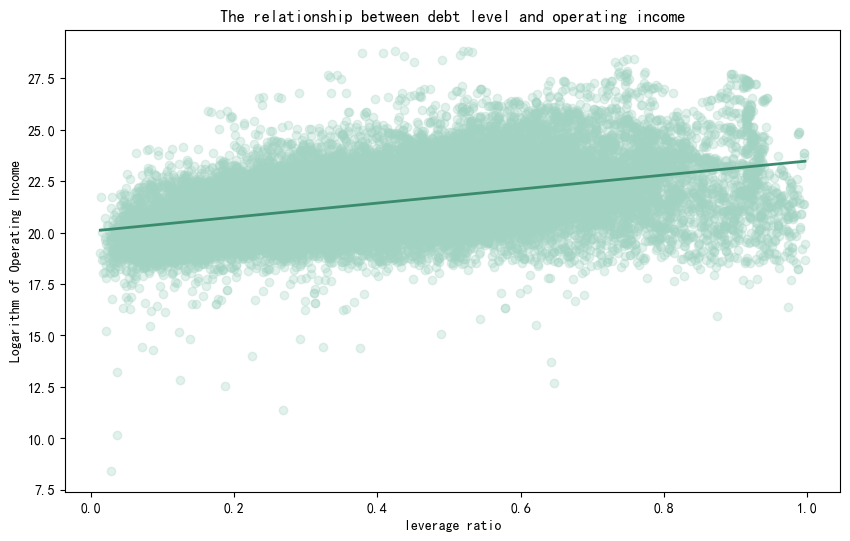

In [78]:
plt.figure(figsize=(10,6))
sns.regplot(
    x=df_clean['lev'], 
    y=df_clean['log_revt'],
    ci=None, 
    scatter_kws={'color':'#A2D3C2', 'alpha':0.3},
    line_kws={'color':'#3B8C6E', 'lw':2}
)
plt.xlabel('leverage ratio')
plt.ylabel('Logarithm of Operating Income')
plt.title('The relationship between debt level and operating income')
plt.show()